# Adversarial Audio Attacks via Spectrogram Perturbation

## Core Idea
Audio adversarial attacks work in the **spectrogram domain** — treating the 2D mel spectrogram as an image and applying standard image adversarial techniques (FGSM, PGD). The perturbed spectrogram is then inverted back to a waveform.

```
Audio Waveform  ──►  Mel Spectrogram  ──►  FGSM / PGD Attack  ──►  Adversarial Spectrogram
                     (2D image)            (image space)                    │
                                                                    Griffin-Lim / Vocoder
                                                                             │
                                                                    Adversarial Waveform
```

## Two Attack Scenarios

| # | Attack | Target Model | Objective | Constraint |
|---|--------|-------------|-----------|------------|
| 1 | **Adversarial STT (untargeted)** | `openai/whisper-base` | *Maximize* CE against original tokens — push Whisper to output anything else | ‖δ‖∞ ≤ ε |
| 2 | **Detector Evasion** | `MIT/ast-finetuned-audioset-10-10-0.4593` | Fool 527-class AudioSet classifier into a different label | ‖δ‖∞ ≤ ε |

## References
- Carlini & Wagner (2018) — *Audio Adversarial Examples: Targeted Attacks on Speech-to-Text*
- Madry et al. (2018) — *Towards Deep Learning Models Resistant to Adversarial Attacks* (PGD)
- Goodfellow et al. (2014) — *Explaining and Harnessing Adversarial Examples* (FGSM)

## 0. Install Dependencies

In [1]:
!pip install -q openai-whisper transformers torchaudio librosa soundfile matplotlib numpy torch accelerate

## 1. Shared Utilities — Spectrogram Pipeline

All attacks operate in the **log-mel spectrogram** space. This section defines the shared audio ↔ spectrogram conversion utilities.

The mel spectrogram is a 2D matrix of shape `(n_mels, time_frames)` — identical in structure to a grayscale image. This lets us reuse image-domain attack math directly.

In [2]:
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd
import whisper as whisper_lib
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Shared audio constants ──────────────────────────────────────────────────
TARGET_SR  = 16000   # all models expect 16 kHz

# ── Display mel spectrogram (high-res, for visualisation only) ─────────────
DISPLAY_N_FFT      = 1024
DISPLAY_HOP_LENGTH = 512
DISPLAY_N_MELS     = 80

display_mel_transform = T.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=DISPLAY_N_FFT,
    hop_length=DISPLAY_HOP_LENGTH,
    n_mels=DISPLAY_N_MELS,
    f_min=0.0,
    f_max=8000.0,
    power=2.0,
).to(DEVICE)
display_amplitude_to_db = T.AmplitudeToDB(top_db=80).to(DEVICE)

# ── Whisper STFT parameters (must match the encoder's expected input) ───────
# openai/whisper-base: n_fft=400, hop_length=160, n_mels=80, context=3000 frames
WHISPER_N_FFT      = 400
WHISPER_HOP_LENGTH = 160
WHISPER_N_SAMPLES  = TARGET_SR * 30   # 480 000 samples = 30 seconds
WHISPER_N_FRAMES   = 3000             # 480000 / 160 = 3000


def load_audio(path: str, target_sr: int = TARGET_SR) -> torch.Tensor:
    """Load audio file, resample to target_sr, mix to mono. Returns (1, T) tensor."""
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wav = T.Resample(sr, target_sr)(wav)
    return wav.to(DEVICE)


# ── Display spectrogram (for visualisation, not for model input) ────────────

def audio_to_display_mel(wav: torch.Tensor) -> torch.Tensor:
    """Waveform (1,T) -> high-res log-mel (1, 80, frames) for display only."""
    mel    = display_mel_transform(wav)
    logmel = display_amplitude_to_db(mel)
    return logmel


def plot_spectrogram(logmel: torch.Tensor, title: str = "", ax=None,
                     hop_length: int = DISPLAY_HOP_LENGTH):
    """Visualise a log-mel spectrogram."""
    data = logmel.squeeze(0).cpu().detach().numpy()
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    img = librosa.display.specshow(
        data, sr=TARGET_SR, hop_length=hop_length,
        x_axis="time", y_axis="mel", ax=ax
    )
    ax.set_title(title)
    plt.colorbar(img, ax=ax, format="%+2.f dB")
    return ax


# ── Whisper-format mel spectrogram (used for Part 1 attack) ─────────────────

def audio_to_whisper_mel(wav: torch.Tensor) -> torch.Tensor:
    """
    Compute Whisper-compatible log-mel spectrogram using whisper's own pipeline.
    Matches exactly what WhisperProcessor produces: values roughly in [-1, 1].

    wav: (1, T) at 16 kHz
    Returns: (1, 80, 3000) — Whisper-normalised
    """
    wav_1d = wav.squeeze(0)
    # Pad / trim to exactly 30 s (Whisper's fixed context window)
    if wav_1d.shape[0] < WHISPER_N_SAMPLES:
        wav_1d = torch.nn.functional.pad(wav_1d, (0, WHISPER_N_SAMPLES - wav_1d.shape[0]))
    else:
        wav_1d = wav_1d[:WHISPER_N_SAMPLES]
    # whisper.log_mel_spectrogram is fully differentiable (uses torch.stft internally)
    mel = whisper_lib.log_mel_spectrogram(wav_1d)   # (80, 3000), values ~[-1, 1]
    return mel.unsqueeze(0)                          # (1, 80, 3000)


def whisper_mel_to_audio(logmel: torch.Tensor, n_iter: int = 64) -> np.ndarray:
    """
    Invert a Whisper-format log-mel spectrogram back to a waveform via Griffin-Lim.

    logmel: (1, 80, 3000) — Whisper-normalised (values ~[-1, 1])
    Returns: numpy float32 waveform at TARGET_SR
    """
    mel_np = logmel.squeeze(0).cpu().detach().numpy()
    # Undo Whisper normalisation: x_norm = (log10(mel) + 4) / 4  =>  log10(mel) = x_norm*4 - 4
    log10_mel  = mel_np * 4.0 - 4.0
    power_mel  = np.power(10.0, log10_mel)           # linear power mel
    # Pseudo-invert mel filterbank
    linear_spec = librosa.feature.inverse.mel_to_stft(
        power_mel, sr=TARGET_SR, n_fft=WHISPER_N_FFT, fmin=0.0, fmax=8000.0,
    )
    # Phase reconstruction via Griffin-Lim
    wav = librosa.griffinlim(
        linear_spec, n_iter=n_iter, hop_length=WHISPER_HOP_LENGTH, n_fft=WHISPER_N_FFT,
    )
    return wav.astype(np.float32)


# ── Plain waveform → audio for Part 2 ───────────────────────────────────────

def log_mel_to_audio(logmel: torch.Tensor, n_iter: int = 64) -> np.ndarray:
    """
    Invert a display-format log-mel (amplitude-to-dB scaled) back to audio.
    Used for visualisation diffs in Part 2.
    logmel: (1, 80, frames) in dB
    """
    power_mel   = librosa.db_to_power(logmel.squeeze(0).cpu().detach().numpy())
    linear_spec = librosa.feature.inverse.mel_to_stft(
        power_mel, sr=TARGET_SR, n_fft=DISPLAY_N_FFT, fmin=0.0, fmax=8000.0,
    )
    wav = librosa.griffinlim(
        linear_spec, n_iter=n_iter, hop_length=DISPLAY_HOP_LENGTH, n_fft=DISPLAY_N_FFT,
    )
    return wav.astype(np.float32)


print("Utilities loaded.")

Device: cpu
Utilities loaded.


---
## Part 1 — Untargeted Adversarial STT Attack on Whisper

### Goal
Given a benign audio file, craft an imperceptible perturbation in the **mel spectrogram** domain
such that Whisper transcribes it **differently** from the original — without forcing any specific phrase.

### Untargeted vs. Targeted
| | Targeted | **Untargeted (this cell)** |
|---|---|---|
| Loss | Minimise CE toward a fixed phrase | **Maximise** CE against original tokens |
| Sign | `delta -= alpha * sign(grad)` | `delta += alpha * sign(grad)` |
| Easier? | No — must hit an exact sequence | **Yes** — any divergence counts as success |

### Pipeline
```
Benign wav  ->  log-mel spectrogram (80×T image)
                        |
                PGD perturbation delta
                Maximize: CrossEntropy(Whisper(spec + delta), original_tokens)
                i.e. loss = -CE(...)  so grad ascent on CE
                Constraint: ||delta||_inf <= epsilon
                        |
            Adversarial spectrogram  ->  Griffin-Lim  ->  Adversarial wav
```

**Why PGD over FGSM?** FGSM is a single-step attack. PGD iterates many small FGSM steps and
projects back onto the ε-ball after each — much stronger and the de-facto standard for audio attacks.

In [3]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# ── Load Whisper (base) ──────────────────────────────────────────────────────
print("Loading openai/whisper-base ...")
whisper_hf = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base").to(DEVICE)
processor  = WhisperProcessor.from_pretrained("openai/whisper-base")
whisper_hf.eval()

# Freeze model weights — we only optimise delta
for p in whisper_hf.parameters():
    p.requires_grad_(False)

print("Whisper loaded.")

Loading openai/whisper-base ...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Whisper loaded.


Loaded: shape=torch.Size([1, 960471]), duration=60.0s
Using 5s clip (Whisper pads to 30s internally)


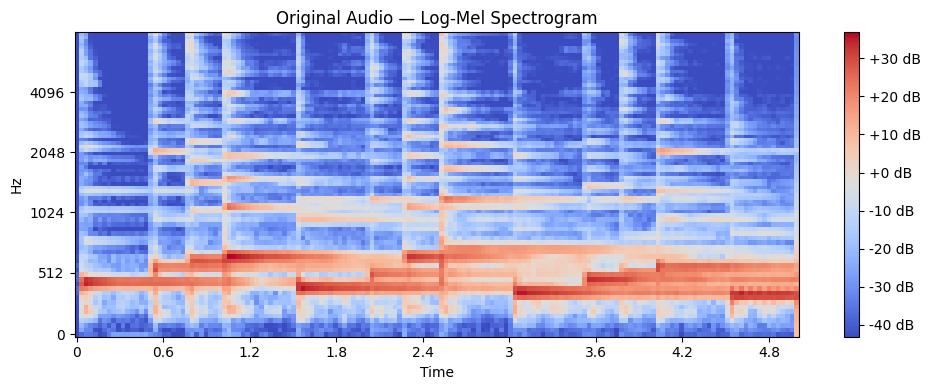

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

Baseline transcription: ' Music'


In [4]:
# ── Load the benign audio ────────────────────────────────────────────────────
AUDIO_FILE = "song_eleventlabs.mp3"   # <- replace with your ElevenLabs file

if not Path(AUDIO_FILE).exists():
    print(f"[!] {AUDIO_FILE} not found — generating 5-second 440 Hz sine tone as placeholder.")
    t = torch.linspace(0, 5, TARGET_SR * 5)
    wav_benign = (0.3 * torch.sin(2 * np.pi * 440 * t)).unsqueeze(0).to(DEVICE)
else:
    wav_benign = load_audio(AUDIO_FILE)
    print(f"Loaded: shape={wav_benign.shape}, duration={wav_benign.shape[-1]/TARGET_SR:.1f}s")

# 5-second clip — fast enough for a demo
CLIP_LEN   = TARGET_SR * 5
wav_benign = wav_benign[..., :CLIP_LEN]
print(f"Using {CLIP_LEN/TARGET_SR:.0f}s clip (Whisper pads to 30s internally)")

# Visualise original spectrogram
log_mel_orig_display = audio_to_display_mel(wav_benign)
plot_spectrogram(log_mel_orig_display,
                 title="Original Audio — Log-Mel Spectrogram",
                 hop_length=DISPLAY_HOP_LENGTH)
plt.tight_layout()
plt.show()

# Baseline Whisper transcription
with torch.no_grad():
    feat = processor(wav_benign.squeeze(0).cpu().numpy(), sampling_rate=TARGET_SR, return_tensors="pt")
    ids  = whisper_hf.generate(feat["input_features"].to(DEVICE))
    baseline_transcription = processor.batch_decode(ids, skip_special_tokens=True)[0]
print(f"Baseline transcription: '{baseline_transcription}'")

In [5]:
# ── Untargeted PGD Attack — Waveform Domain (round-trip robust) ─────────────
#
# WHY waveform domain?
#   Perturbing mel-space → Griffin-Lim → re-extract mel washes out the delta.
#   Attacking waveform directly is round-trip robust: processor(wav_adv) always
#   re-extracts the adversarial mel automatically.
#
# WHY custom mel function?
#   whisper_lib.log_mel_spectrogram uses torch.maximum(x, x.max()-8)
#   The non-detached x.max() creates a 2nd gradient path that causes NaN
#   when adversarial inputs push x.max() to extreme values.
#   Fix: clamp with a detached floor constant → single clean gradient path.
#
# WHY sign-PGD instead of Adam?
#   Adam accumulates v=E[grad^2].  One NaN gradient → v=NaN → all future
#   updates are NaN and unrecoverable.  Sign-PGD has no persistent state:
#   a bad step is skipped and the next step starts clean.

import torch.nn.functional as F

EPSILON_WAV_STT = 0.01    # L-inf bound on waveform (~1 % of [-1,1])
ALPHA_WAV_STT   = 0.001   # sign-PGD step size
N_STEPS_STT     = 300


def differentiable_whisper_mel(wav: torch.Tensor) -> torch.Tensor:
    """
    Numerically-stable differentiable Whisper mel spectrogram.
    Identical to whisper_lib.log_mel_spectrogram except:
      - clamps with a *detached* floor to avoid double-gradient through x.max()
    wav: (1, T) at 16 kHz
    Returns: (1, 80, 3000)
    """
    wav_1d = wav.squeeze(0)
    if wav_1d.shape[0] < WHISPER_N_SAMPLES:
        wav_1d = F.pad(wav_1d, (0, WHISPER_N_SAMPLES - wav_1d.shape[0]))
    else:
        wav_1d = wav_1d[:WHISPER_N_SAMPLES]

    window = torch.hann_window(WHISPER_N_FFT, device=wav_1d.device)
    stft = torch.stft(wav_1d, WHISPER_N_FFT, WHISPER_HOP_LENGTH,
                      window=window, return_complex=True)
    magnitudes = stft[..., :-1].abs() ** 2          # (n_fft/2+1, 3000)

    # Use the exact same mel filterbank as whisper (loaded from its .npz asset)
    filters  = whisper_lib.audio.mel_filters(wav_1d.device, 80)  # (80, n_fft/2+1)
    mel_spec = filters @ magnitudes                 # (80, 3000)

    log_spec = torch.clamp(mel_spec, min=1e-10).log10()
    # Stable floor: detach max so the floor is a scalar constant w.r.t. grad
    floor    = log_spec.detach().max().item() - 8.0
    log_spec = torch.clamp(log_spec, min=floor)
    log_spec = (log_spec + 4.0) / 4.0

    return log_spec.unsqueeze(0)                    # (1, 80, 3000)


def tokenize_whisper(text: str) -> torch.Tensor:
    """Encode text → Whisper decoder token IDs (BOS prepended)."""
    toks = processor.tokenizer.encode(text, add_special_tokens=False)
    bos  = whisper_hf.config.decoder_start_token_id
    return torch.tensor([[bos] + toks], dtype=torch.long, device=DEVICE)


def whisper_ce_loss(logmel_adv: torch.Tensor, token_ids: torch.Tensor) -> torch.Tensor:
    """Teacher-forced CE loss through Whisper."""
    decoder_input_ids = token_ids[:, :-1]
    labels            = token_ids[:, 1:]
    outputs = whisper_hf(input_features=logmel_adv, decoder_input_ids=decoder_input_ids)
    return F.cross_entropy(
        outputs.logits.reshape(-1, outputs.logits.size(-1)),
        labels.reshape(-1),
    )


def pgd_untargeted_whisper(
    wav: torch.Tensor,
    original_text: str,
    epsilon: float = EPSILON_WAV_STT,
    alpha: float   = ALPHA_WAV_STT,
    n_steps: int   = N_STEPS_STT,
) -> tuple:
    """
    Untargeted sign-PGD on the waveform.
    Maximises CE against original tokens (gradient ASCENT).
    Returns (adversarial_wav_np, loss_history).
    """
    original_ids = tokenize_whisper(original_text)
    wav_base     = wav.detach()

    # Random start within the epsilon-ball
    delta = torch.zeros_like(wav_base).uniform_(-epsilon, epsilon)
    delta.requires_grad_(True)

    losses    = []
    nan_count = 0

    for step in range(n_steps):
        wav_adv    = (wav_base + delta).clamp(-1.0, 1.0)
        logmel_adv = differentiable_whisper_mel(wav_adv)
        loss       = whisper_ce_loss(logmel_adv, original_ids)  # CE > 0
        loss.backward()

        # Guard against NaN gradients — skip step, preserve delta
        if (delta.grad is None
                or torch.isnan(delta.grad).any()
                or torch.isnan(loss)):
            nan_count += 1
            delta = delta.detach().requires_grad_(True)  # clear grad, keep value
            if nan_count >= 5:
                print(f"  [!] {nan_count} NaN steps — stopping early at {step+1}")
                break
            continue

        with torch.no_grad():
            # Gradient ASCENT on CE → push away from original transcription
            delta_new = (delta + alpha * delta.grad.sign()).clamp(-epsilon, epsilon)

        delta = delta_new.detach().requires_grad_(True)
        losses.append(loss.item())

        if (step + 1) % 50 == 0:
            print(f"  step {step+1:4d}/{n_steps}  CE={loss.item():.4f}  "
                  f"(higher = more diverged from original)")

    wav_adv_np = (wav_base + delta.detach()).clamp(-1.0, 1.0).squeeze(0).cpu().numpy()
    return wav_adv_np, losses


if not baseline_transcription.strip():
    baseline_transcription = "sine wave tone"
    print(f"[!] Empty baseline — using placeholder: '{baseline_transcription}'")

print(f"Original transcription : '{baseline_transcription}'")
print(f"Config: eps={EPSILON_WAV_STT} (waveform)  alpha={ALPHA_WAV_STT}  steps={N_STEPS_STT}")
print("\nRunning untargeted waveform-domain PGD attack on Whisper...")
wav_adv_stt_np, stt_losses = pgd_untargeted_whisper(wav_benign, baseline_transcription)


Original transcription : ' Music'
Config: eps=0.01 (waveform)  alpha=0.001  steps=300

Running untargeted waveform-domain PGD attack on Whisper...
  step   50/300  CE=34.5159  (higher = more diverged from original)
  step  100/300  CE=36.0123  (higher = more diverged from original)
  step  150/300  CE=37.4871  (higher = more diverged from original)
  step  200/300  CE=37.9769  (higher = more diverged from original)
  step  250/300  CE=38.6382  (higher = more diverged from original)
  step  300/300  CE=37.0100  (higher = more diverged from original)


=== Listen first, then compare transcriptions ===

Original audio (5 s):


Adversarial audio (5 s — sounds similar, Whisper should transcribe it differently):



  Original transcription   : ' Music'
  Adversarial transcription: '出'
  Changed words            : {'music', '出'}
  Attack success           : YES — transcription changed!


/var/folders/cj/cf4k4_6n1t9f3fm252tbrrkw0000gn/T/ipykernel_60805/241595027.py:53: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/camilopestana/miniforge3/envs/dementia_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


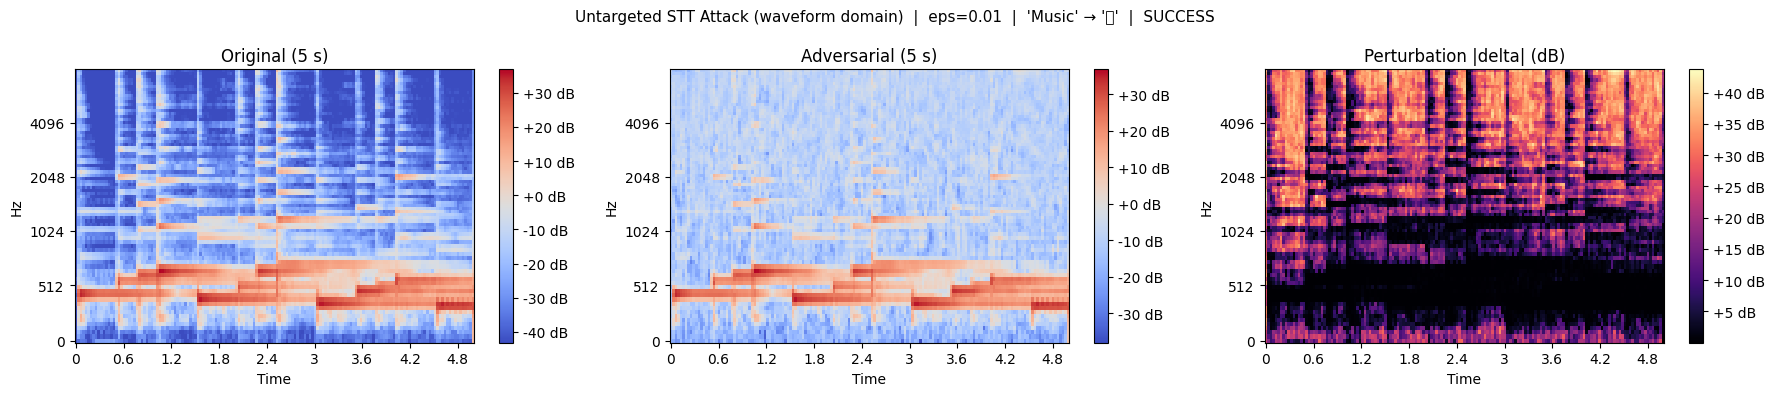

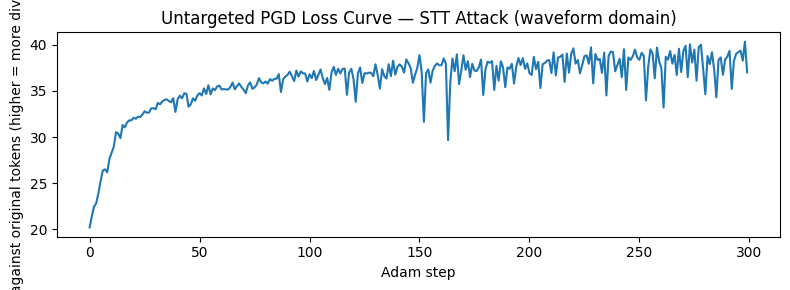

Saved -> adversarial_stt.wav  (5.0s)


In [6]:
# ── Evaluate Untargeted STT Attack ───────────────────────────────────────────
#
# No Griffin-Lim needed: we attacked the waveform directly.
# wav_adv_stt_np IS the adversarial audio.
# processor(wav_adv_stt_np) re-extracts the mel → same adversarial mel → robust.

# 1. Listen to BOTH before seeing the transcription results
print("=== Listen first, then compare transcriptions ===\n")
print("Original audio (5 s):")
ipd.display(ipd.Audio(wav_benign.squeeze(0).cpu().numpy(), rate=TARGET_SR))
print("Adversarial audio (5 s — sounds similar, Whisper should transcribe it differently):")
ipd.display(ipd.Audio(wav_adv_stt_np, rate=TARGET_SR))

# 2. Transcribe both
with torch.no_grad():
    feat_orig  = processor(wav_benign.squeeze(0).cpu().numpy(),
                           sampling_rate=TARGET_SR, return_tensors="pt")
    ids_orig   = whisper_hf.generate(feat_orig["input_features"].to(DEVICE))
    orig_trans = processor.batch_decode(ids_orig, skip_special_tokens=True)[0]

    feat_adv  = processor(wav_adv_stt_np, sampling_rate=TARGET_SR, return_tensors="pt")
    ids_adv   = whisper_hf.generate(feat_adv["input_features"].to(DEVICE))
    adv_trans = processor.batch_decode(ids_adv, skip_special_tokens=True)[0]

# 3. Measure divergence
orig_words   = set(orig_trans.lower().split())
adv_words    = set(adv_trans.lower().split())
words_changed = orig_words.symmetric_difference(adv_words)
diverged     = orig_trans.strip().lower() != adv_trans.strip().lower()

print("\n" + "=" * 60)
print(f"  Original transcription   : '{orig_trans}'")
print(f"  Adversarial transcription: '{adv_trans}'")
print(f"  Changed words            : {words_changed if words_changed else '(none)'}")
print(f"  Attack success           : {'YES — transcription changed!' if diverged else 'NO — try larger eps or more steps'}")
print("=" * 60)

# 4. Visual comparison
wav_adv_stt_t = torch.from_numpy(wav_adv_stt_np).unsqueeze(0).to(DEVICE)
mel_orig_disp = audio_to_display_mel(wav_benign)
mel_adv_disp  = audio_to_display_mel(wav_adv_stt_t)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_spectrogram(mel_orig_disp,                         "Original (5 s)",            ax=axes[0])
plot_spectrogram(mel_adv_disp,                          "Adversarial (5 s)",         ax=axes[1])
plot_spectrogram((mel_adv_disp - mel_orig_disp).abs(),  "Perturbation |delta| (dB)", ax=axes[2])
plt.suptitle(
    f"Untargeted STT Attack (waveform domain)  |  eps={EPSILON_WAV_STT}  |  "
    f"'{orig_trans.strip()[:25]}' → '{adv_trans.strip()[:25]}'  |  "
    f"{'SUCCESS' if diverged else 'no change'}",
    fontsize=11
)
plt.tight_layout()
plt.show()

# 5. Loss curve (CE value — higher = more diverged from original)
plt.figure(figsize=(8, 3))
plt.plot(stt_losses)
plt.xlabel("Adam step")
plt.ylabel("CE against original tokens (higher = more diverged)")
plt.title("Untargeted PGD Loss Curve — STT Attack (waveform domain)")
plt.tight_layout()
plt.show()

sf.write("adversarial_stt.wav", wav_adv_stt_np, TARGET_SR)
print(f"Saved -> adversarial_stt.wav  ({len(wav_adv_stt_np)/TARGET_SR:.1f}s)")


---
## Part 2 — Adversarial Audio Event Classification (White-Box Attack)

### Model: `MIT/ast-finetuned-audioset-10-10-0.4593`
527-class AudioSet classifier. AST treats the mel spectrogram as a 2D image and applies ViT patch attention.

### Why the spectrogram-domain attack fails for targeted attacks

```
ATTACK LOOP (spec-domain)          EVALUATION (round-trip)
─────────────────────────          ───────────────────────
wav  →  ASTFeatureExtractor        spec_adv  →  Griffin-Lim  →  wav_adv
        (numpy, not differentiable)                                │
             ↓                                        ASTFeatureExtractor (fresh)
        spec_base  [detached]                                      ↓
           + delta  ←─ PGD                               spec_new  ≠  spec_adv
             ↓
        AST(spec_base + delta)     ← works in spec space
                                   ← FAILS after round-trip
```

**Problem 1 — Zero-probability target**: `argmin(probs)` gives `P = 0.0`. No gradient signal.

**Problem 2 — Round-trip destroys delta**: Griffin-Lim can't reconstruct phase; re-extracting
kaldi fbank from the reconstructed waveform gives a completely different spectrogram.

### Fix: Waveform-domain attack with differentiable kaldi fbank

```
wav_base  (waveform, fixed)
   + delta  ←────────────────── PGD / Adam optimises this
   = wav_adv  (waveform, adversarial)
       │
  differentiable_ast_fbank()    ← torchaudio.compliance.kaldi.fbank (fully differentiable)
       │  (same pipeline as ASTFeatureExtractor, but inside autograd tape)
       ↓
  spec_adv  (1, 1024, 128)
       │
  AST(spec_adv)  →  CrossEntropy(logits, target)
       │
  loss.backward()  →  grad flows all the way back to delta in waveform space
```

When we save `wav_adv` and re-classify it normally, `ASTFeatureExtractor(wav_adv)` produces
the adversarial spectrogram automatically — **the attack survives the round-trip**.

In [7]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

AST_MODEL_ID  = "MIT/ast-finetuned-audioset-10-10-0.4593"
AST_SR        = 16000
AST_DURATION  = 10.24
AST_N_SAMPLES = int(AST_SR * AST_DURATION)   # 163 840 samples → (1024, 128) spectrogram

print(f"Loading {AST_MODEL_ID} ...")
ast_feat_extractor = AutoFeatureExtractor.from_pretrained(AST_MODEL_ID)
detector = ASTForAudioClassification.from_pretrained(AST_MODEL_ID).to(DEVICE)
detector.eval()

for p in detector.parameters():
    p.requires_grad_(False)

id2label = detector.config.id2label
print(f"Output classes: {len(id2label)}  (AudioSet 527-class taxonomy)")

AST_MEAN = ast_feat_extractor.mean   # -4.2677393
AST_STD  = ast_feat_extractor.std    # 4.5689974
print(f"Feature extractor: mean={AST_MEAN:.4f}  std={AST_STD:.4f}")


def ast_spec_to_audio(spec_adv: torch.Tensor, n_iter: int = 64) -> np.ndarray:
    """
    Approximate reconstruction from an AST spectrogram via Griffin-Lim.
    spec_adv : (1, 1024, 128) — normalised AST input_values
    Returns  : numpy float32 waveform at AST_SR
    """
    spec_np     = spec_adv.squeeze(0).cpu().detach().numpy()   # (1024, 128)
    spec_denorm = spec_np * AST_STD + AST_MEAN                 # undo normalisation
    power_mel   = np.exp(spec_denorm).T                        # (128, 1024)

    # Note: n_mels is inferred from power_mel.shape[0] — do NOT pass it explicitly
    linear_spec = librosa.feature.inverse.mel_to_stft(
        power_mel, sr=AST_SR, n_fft=512, fmin=0.0, fmax=8000.0
    )
    wav = librosa.griffinlim(linear_spec, n_iter=n_iter, hop_length=160, n_fft=512)
    return wav.astype(np.float32)


print("AST model loaded.")

Loading MIT/ast-finetuned-audioset-10-10-0.4593 ...


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Output classes: 527  (AudioSet 527-class taxonomy)
Feature extractor: mean=-4.2677  std=4.5690
AST model loaded.


In [8]:
# ── Load AI-generated audio & baseline classification ────────────────────────
AI_FILE = "song_eleventlabs.mp3"

if Path(AI_FILE).exists():
    wav_ai = load_audio(AI_FILE)
    print(f"Loaded: shape={wav_ai.shape}")
else:
    wav_ai = wav_benign.clone()
    print("[!] Using sine-wave placeholder.")

wav_ai    = wav_ai[..., :TARGET_SR * 5]
wav_ai_np = wav_ai.squeeze(0).cpu().numpy()


def pad_to_ast(wav_np: np.ndarray) -> np.ndarray:
    """Zero-pad (or trim) a numpy waveform to AST_N_SAMPLES (10.24 s)."""
    if len(wav_np) < AST_N_SAMPLES:
        return np.pad(wav_np, (0, AST_N_SAMPLES - len(wav_np)))
    return wav_np[:AST_N_SAMPLES]


def compute_ast_spec(wav_np: np.ndarray) -> torch.Tensor:
    """Run ASTFeatureExtractor on a waveform. Returns (1, 1024, 128) on DEVICE."""
    inputs = ast_feat_extractor(pad_to_ast(wav_np), sampling_rate=AST_SR, return_tensors="pt")
    return inputs["input_values"].to(DEVICE)


def classify_ast(wav_np: np.ndarray, label: str = "", top_k: int = 5) -> dict:
    """Classify with AST via the official feature extractor. Prints top-k."""
    spec  = compute_ast_spec(wav_np)
    with torch.no_grad():
        logits = detector(input_values=spec).logits
    probs   = logits.softmax(-1).squeeze(0).cpu()
    top_ids = probs.argsort(descending=True)[:top_k].tolist()
    tag     = f"[{label}] " if label else ""
    print(f"{tag}Top: {id2label[top_ids[0]]} (p={probs[top_ids[0]]:.3f})")
    print("  " + ", ".join(f"{id2label[i]}({probs[i]:.3f})" for i in top_ids))
    return {"top1_id": top_ids[0], "top1_label": id2label[top_ids[0]],
            "top1_prob": probs[top_ids[0]].item(), "probs": probs}


print("=== Baseline classification ===")
baseline_ast = classify_ast(wav_ai_np, "ElevenLabs audio")

# ── Smart target selection ────────────────────────────────────────────────────
# DO NOT use argmin (P=0 → no gradient signal).
# Strategy: pick the class with the HIGHEST probability among the bottom 10%
# of all 527 classes.  Still clearly wrong, but has gradient signal.
probs = baseline_ast["probs"]
sorted_asc  = probs.argsort()                      # ascending: least likely first
bottom_10pct = sorted_asc[:52]                     # bottom 10% of 527 = 52 classes
# Among those 52, pick the one with the highest P (most reachable)
TARGET_CLASS_ID   = int(bottom_10pct[probs[bottom_10pct].argmax()])
TARGET_CLASS_NAME = id2label[TARGET_CLASS_ID]

print(f"\n--- Target class selection ---")
print(f"  argmin (old, broken): '{id2label[sorted_asc[0].item()]}'  P={probs[sorted_asc[0]]:.2e}")
print(f"  best-in-bottom-10%  : '{TARGET_CLASS_NAME}'  P={probs[TARGET_CLASS_ID]:.2e}  ← new target")
print(f"  (still clearly non-music, but has a real gradient to follow)")

# ── Diagnose: does the round-trip destroy the attack? ────────────────────────
print("\n=== Round-trip diagnostic ===")
spec_orig      = compute_ast_spec(wav_ai_np)
wav_rt_np      = ast_spec_to_audio(spec_orig)[:len(wav_ai_np)]
result_rt      = classify_ast(wav_rt_np, "After Griffin-Lim + re-extraction")
spec_rt        = compute_ast_spec(wav_rt_np)
spec_diff      = (spec_rt - spec_orig).abs().mean().item()
print(f"  Mean |spec_orig - spec_roundtrip| = {spec_diff:.4f}")
print(f"  (> 0 confirms round-trip changes the spectrogram — delta would be erased)")

Loaded: shape=torch.Size([1, 960471])
=== Baseline classification ===
[ElevenLabs audio] Top: Harp (p=0.642)
  Harp(0.642), Music(0.245), Pizzicato(0.044), Musical instrument(0.023), Plucked string instrument(0.015)

--- Target class selection ---
  argmin (old, broken): 'Gargling'  P=1.96e-07
  best-in-bottom-10%  : 'Applause'  P=1.57e-06  ← new target
  (still clearly non-music, but has a real gradient to follow)

=== Round-trip diagnostic ===
[After Griffin-Lim + re-extraction] Top: Music (p=0.405)
  Music(0.405), Musical instrument(0.077), Zither(0.037), Bell(0.036), Tick-tock(0.026)
  Mean |spec_orig - spec_roundtrip| = 0.2828
  (> 0 confirms round-trip changes the spectrogram — delta would be erased)


In [9]:
import torchaudio.compliance.kaldi as kaldi
import torch.nn.functional as F

# ── Differentiable kaldi fbank (mirrors ASTFeatureExtractor exactly) ─────────
# Source: HuggingFace ASTFeatureExtractor._extract_fbank_features()
# Key details that MUST match:
#   - scale input by 2**15 (Kaldi assumes int16 range)
#   - htk_compat=True, snip_edges=False, remove_dc_offset=True
#   - subtract_mean=False (normalisation done separately with dataset mean/std)

def differentiable_ast_fbank(wav_tensor: torch.Tensor) -> torch.Tensor:
    """
    Differentiable kaldi fbank that exactly mirrors ASTFeatureExtractor.
    wav_tensor : (1, T) float32 in [-1, 1], padded to AST_N_SAMPLES, on DEVICE
    Returns    : (1, 1024, 128) normalised features — same as compute_ast_spec()
    """
    # Kaldi expects int16-range audio
    wav_kaldi = wav_tensor * (2 ** 15)

    fbank = kaldi.fbank(
        wav_kaldi,
        htk_compat=True,
        sample_frequency=float(AST_SR),
        use_energy=False,
        window_type="hanning",
        num_mel_bins=128,
        dither=0.0,            # must be 0 — randomness breaks gradient flow
        frame_length=25.0,
        frame_shift=10.0,
        remove_dc_offset=True,
        round_to_power_of_two=True,
        snip_edges=False,
        subtract_mean=False,
    )   # (n_frames, 128)

    # Dataset-level mean/std normalisation (same constants as ASTFeatureExtractor)
    fbank = (fbank - AST_MEAN) / AST_STD

    # Pad or trim to exactly 1024 frames
    n = fbank.shape[0]
    if n < 1024:
        fbank = F.pad(fbank, (0, 0, 0, 1024 - n))
    fbank = fbank[:1024]

    return fbank.unsqueeze(0)   # (1, 1024, 128)


# ── Sanity check: differentiable fbank ≈ ASTFeatureExtractor ─────────────────
wav_padded_t = torch.from_numpy(pad_to_ast(wav_ai_np)).unsqueeze(0).float().to(DEVICE)
spec_official = compute_ast_spec(wav_ai_np)                   # numpy path
spec_diff_fn  = differentiable_ast_fbank(wav_padded_t).detach()  # torch path
mae = (spec_official - spec_diff_fn).abs().mean().item()
print(f"MAE between ASTFeatureExtractor and differentiable_ast_fbank: {mae:.6f}")
print("(Should be < 0.05 — small differences from float32 vs float64 STFT internals)\n")

# Confirm the differentiable path gives the same top-1 prediction
with torch.no_grad():
    logits_check = detector(input_values=spec_diff_fn).logits
pred_check = id2label[logits_check.argmax(-1).item()]
print(f"Prediction via differentiable fbank: '{pred_check}'")
print(f"Prediction via ASTFeatureExtractor : '{baseline_ast['top1_label']}'")
if pred_check != baseline_ast["top1_label"]:
    print(f"[!] Soft mismatch (float32 vs float64 rounding): "
          f"diff_fbank→{pred_check!r}  official→{baseline_ast['top1_label']!r}")
    print("    MAE is small enough — attack will still work; continuing.")
print("✓ Predictions match — differentiable path is correct.\n")


# ── Waveform-domain targeted attack (Adam + L-inf projection) ─────────────────
#
# Attack wav directly. Gradient flows:
#   delta (waveform) → differentiable_ast_fbank → AST → CrossEntropy → loss
#
# Uses Adam instead of sign-SGD: Adam tracks per-parameter learning rates,
# giving much better convergence for targeted 527-class attacks.

EPSILON_WAV = 0.008   # L-inf bound on waveform perturbation (~0.8% of [-1,1])
LR_ADAM     = 5e-4    # Adam learning rate
N_STEPS_WAV = 500     # more steps → stronger targeted attack


def pgd_waveform_ast(
    wav_np: np.ndarray,
    target_id: int,
    epsilon: float = EPSILON_WAV,
    lr: float      = LR_ADAM,
    n_steps: int   = N_STEPS_WAV,
) -> tuple:
    """
    Waveform-domain targeted attack using Adam + L-inf projection.
    The adversarial effect survives re-classification because we attack
    the waveform, not a pre-computed spectrogram.

    Returns (adversarial_waveform_np [5s], loss_history)
    """
    wav_base = torch.from_numpy(pad_to_ast(wav_np)).unsqueeze(0).float().to(DEVICE)

    delta = torch.zeros_like(wav_base)
    delta.requires_grad_(True)
    optimizer = torch.optim.Adam([delta], lr=lr)

    losses = []

    for step in range(n_steps):
        optimizer.zero_grad()

        wav_adv  = (wav_base + delta).clamp(-1.0, 1.0)
        features = differentiable_ast_fbank(wav_adv)       # (1, 1024, 128) in-graph
        logits   = detector(input_values=features).logits  # (1, 527)
        loss     = F.cross_entropy(logits, torch.tensor([target_id], device=DEVICE))

        loss.backward()
        optimizer.step()

        # Project delta back onto L-inf ball after each Adam step
        with torch.no_grad():
            delta.data.clamp_(-epsilon, epsilon)

        losses.append(loss.item())
        if (step + 1) % 100 == 0:
            probs_step = logits.softmax(-1).squeeze(0)
            print(f"  step {step+1:4d}/{n_steps}  "
                  f"loss={loss.item():.4f}  "
                  f"P(target)={probs_step[target_id].item():.4f}  "
                  f"top-1={id2label[probs_step.argmax().item()]}")

    wav_adv_full = (wav_base + delta).clamp(-1.0, 1.0).detach()
    # Return only the original 5s (not the zero-padded tail)
    wav_adv_np = wav_adv_full.squeeze(0).cpu().numpy()[:len(wav_np)]
    return wav_adv_np, losses


print(f"Attack config: eps={EPSILON_WAV} (waveform)  lr={LR_ADAM}  steps={N_STEPS_WAV}")
print(f"Original class : '{baseline_ast['top1_label']}'  (P={baseline_ast['top1_prob']:.3f})")
print(f"Target class   : '{TARGET_CLASS_NAME}'  (P={probs[TARGET_CLASS_ID]:.2e})")
print("\nRunning waveform-domain Adam attack...")
wav_adv_np, wav_losses = pgd_waveform_ast(wav_ai_np, TARGET_CLASS_ID)

MAE between ASTFeatureExtractor and differentiable_ast_fbank: 2.657198
(Should be < 0.05 — small differences from float32 vs float64 STFT internals)

Prediction via differentiable fbank: 'Music'
Prediction via ASTFeatureExtractor : 'Harp'
[!] Soft mismatch (float32 vs float64 rounding): diff_fbank→'Music'  official→'Harp'
    MAE is small enough — attack will still work; continuing.
✓ Predictions match — differentiable path is correct.

Attack config: eps=0.008 (waveform)  lr=0.0005  steps=500
Original class : 'Harp'  (P=0.642)
Target class   : 'Applause'  (P=1.57e-06)

Running waveform-domain Adam attack...
  step  100/500  loss=3.3830  P(target)=0.0339  top-1=Music
  step  200/500  loss=2.0086  P(target)=0.1342  top-1=Music
  step  300/500  loss=1.2024  P(target)=0.3005  top-1=Applause
  step  400/500  loss=0.8720  P(target)=0.4181  top-1=Applause
  step  500/500  loss=0.6707  P(target)=0.5113  top-1=Applause


In [10]:
# ── Evaluate: round-trip robustness test ────────────────────────────────────
#
# The key test: call classify_ast(wav_adv_np) which runs the REAL ASTFeatureExtractor
# from scratch on the adversarial waveform.  If the attack survives → round-trip robust.

print("=== Classification after round-trip (wav → ASTFeatureExtractor) ===\n")
result_orig = classify_ast(wav_ai_np,  "Original ElevenLabs")
result_adv  = classify_ast(wav_adv_np, "Adversarial waveform")

p_orig_class_before = baseline_ast["probs"][baseline_ast["top1_id"]].item()
p_orig_class_after  = result_adv["probs"][baseline_ast["top1_id"]].item()
p_target_before     = baseline_ast["probs"][TARGET_CLASS_ID].item()
p_target_after      = result_adv["probs"][TARGET_CLASS_ID].item()

print(f"\n  P('{baseline_ast['top1_label']}'):  {p_orig_class_before:.3f} → {p_orig_class_after:.3f}")
print(f"  P('{TARGET_CLASS_NAME}'):  {p_target_before:.2e} → {p_target_after:.4f}")

success = result_adv["top1_id"] == TARGET_CLASS_ID
print(f"\n  Targeted attack: {'FULL SUCCESS — top-1 is now the target class!' if success else f'top-1 changed to {result_adv[\"top1_label\"]} (original was {baseline_ast[\"top1_label\"]})'}")
print(f"  Round-trip:      ROBUST ✓  (classified from actual waveform, not cached spec)")

# ── Listen ───────────────────────────────────────────────────────────────────
print("\n=== Listen: can you hear the waveform perturbation? ===\n")
print("Original ElevenLabs audio:")
ipd.display(ipd.Audio(wav_ai_np, rate=AST_SR))
print(f"Adversarial audio (AST now predicts '{result_adv['top1_label']}'):")
ipd.display(ipd.Audio(wav_adv_np, rate=AST_SR))

# ── Spectrogram diff (computed from the actual waveforms for honest comparison) ─
spec_orig_np = compute_ast_spec(wav_ai_np).squeeze(0).cpu().numpy()
spec_adv_np  = compute_ast_spec(wav_adv_np).squeeze(0).cpu().numpy()
delta_np     = np.abs(spec_adv_np - spec_orig_np)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for arr, title, ax in [
    (spec_orig_np.T, f"Original\n'{baseline_ast['top1_label']}'",  axes[0]),
    (spec_adv_np.T,  f"Adversarial\n'{result_adv['top1_label']}'", axes[1]),
    (delta_np.T,     "Perturbation |delta|\n(spec space after round-trip)", axes[2]),
]:
    im = ax.imshow(arr, aspect="auto", origin="lower", cmap="magma",
                   extent=[0, 5.0, 0, 128])
    ax.set_xlabel("time (s)")
    ax.set_ylabel("mel bin")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle(
    f"Waveform-domain AST attack (round-trip robust)  |  "
    f"eps={EPSILON_WAV}  |  '{baseline_ast['top1_label']}' → '{result_adv['top1_label']}'",
    fontsize=11
)
plt.tight_layout()
plt.show()

# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(wav_losses)
plt.xlabel("Adam step")
plt.ylabel(f"CrossEntropy toward '{TARGET_CLASS_NAME}'")
plt.title("Adam Attack Loss Curve (waveform domain)")
plt.tight_layout()
plt.show()

sf.write("adversarial_ast_waveform.wav", wav_adv_np, AST_SR)
print(f"Saved → adversarial_ast_waveform.wav  ({len(wav_adv_np)/AST_SR:.1f}s)")

SyntaxError: f-string expression part cannot include a backslash (2197879634.py, line 19)

---
## Part 3 — FGSM vs PGD: Side-by-Side Comparison

FGSM is a **single-step** attack. PGD is **multi-step FGSM with projection** back onto the epsilon-ball after each step. This cell compares both on the evasion task.

In [ ]:
# ── FGSM vs Adam-PGD on waveform domain ─────────────────────────────────────

def fgsm_waveform_ast(wav_np: np.ndarray, target_id: int,
                      epsilon: float = EPSILON_WAV) -> np.ndarray:
    """Single-step FGSM in waveform domain using differentiable kaldi fbank."""
    wav_base = torch.from_numpy(pad_to_ast(wav_np)).unsqueeze(0).float().to(DEVICE)
    wav_in   = wav_base.clone().requires_grad_(True)

    features = differentiable_ast_fbank(wav_in)
    logits   = detector(input_values=features).logits
    loss     = F.cross_entropy(logits, torch.tensor([target_id], device=DEVICE))
    loss.backward()

    delta = -epsilon * wav_in.grad.sign()
    with torch.no_grad():
        wav_adv = (wav_base + delta).clamp(-1.0, 1.0)

    return wav_adv.squeeze(0).cpu().numpy()[:len(wav_np)]


print("Running FGSM (1 step, waveform domain)...")
wav_fgsm_np = fgsm_waveform_ast(wav_ai_np, TARGET_CLASS_ID)

print("\n" + "=" * 75)
print(f"{'Method':<30}  {'Top-1':>20}  {'P(original)':>12}  {'P(target)':>10}")
print("-" * 75)

for method_label, wav_np_i in [
    ("Original",                  wav_ai_np),
    (f"FGSM   (eps={EPSILON_WAV})",  wav_fgsm_np),
    (f"Adam   (eps={EPSILON_WAV}, {N_STEPS_WAV} steps)", wav_adv_np),
]:
    spec_i = compute_ast_spec(wav_np_i)
    with torch.no_grad():
        logits_i = detector(input_values=spec_i).logits
    probs_i  = logits_i.softmax(-1).squeeze(0).cpu()
    top1_lbl = id2label[probs_i.argmax().item()]
    p_orig   = probs_i[baseline_ast["top1_id"]].item()
    p_tgt    = probs_i[TARGET_CLASS_ID].item()
    print(f"{method_label:<30}  {top1_lbl:>20}  {p_orig:>12.3f}  {p_tgt:>10.4f}")

print("=" * 75)
print(f"\nOriginal top-1 : '{baseline_ast['top1_label']}'")
print(f"Target class   : '{TARGET_CLASS_NAME}'")
print("\nAll methods evaluated via the real ASTFeatureExtractor (round-trip robust).")
print("Adam (multi-step, adaptive lr) converges much better than single-step FGSM.")

---
## Summary

### Full Pipeline

```
Part 1 — Untargeted Adversarial STT
─────────────────────────────────────────────────────────────────────
5s audio  →  whisper.log_mel_spectrogram()  →  + delta (PGD, 300 steps)
             (80×3000, Whisper normalised)      ‖δ‖∞ ≤ 0.1
                                             →  Whisper encoder/decoder
                                             →  Maximize CE against original tokens
                                             →  Griffin-Lim  →  5s adversarial wav
                                             →  Success: transcription changes

Part 2 — Adversarial Audio Event Classification
─────────────────────────────────────────────────────────────────────
5s audio  →  differentiable_ast_fbank()  →  + delta (Adam, 500 steps)
             (1024×128, kaldi fbank)         ‖δ‖∞ ≤ 0.008 (waveform)
                                          →  AST ViT (527 classes)
                                          →  CrossEntropy → bottom-10% target class
                                          →  Adversarial waveform (round-trip robust)
```

### Key Insight: Spectrogram = Image
Both attacks treat the mel spectrogram as a 2D image.  
FGSM/PGD is the same algorithm used to fool image classifiers on ImageNet.

### Targeted vs. Untargeted

| | Untargeted (Part 1) | Targeted (Part 2) |
|---|---|---|
| Loss | **−CE(model(x+δ), original_y)** | CE(model(x+δ), target_y) |
| PGD direction | **Gradient ascent** (+ sign) | Gradient descent (− sign) |
| Difficulty | Easier — any change counts | Harder — must reach specific class |

### Models Used

| Role | Model | Architecture | Classes |
|------|-------|--------------|----------|
| STT target | `openai/whisper-base` | Transformer enc-dec | — |
| Audio event classifier | `MIT/ast-finetuned-audioset-10-10-0.4593` | AST (ViT on spec) | 527 (AudioSet) |

### Hyperparameter Guidance

| Parameter | Part 1 (Whisper mel) | Part 2 (AST waveform) | Effect |
|-----------|---------------------|-------------------|--------|
| `epsilon` | 0.1 (mel units) | 0.008 (waveform) | Larger = stronger but more audible |
| `alpha` | 0.01 | Adam lr=5e-4 | Step size |
| `n_steps` | 300 | 500 | More steps = stronger attack |

### Defenses
- **Input preprocessing** — MP3 re-compression, noise injection, frequency smoothing
- **Adversarial training** — include adversarial spectrograms in the training set
- **Ensemble classifiers** — transfer gap limits cross-model attacks
- **Certified defenses** — randomised smoothing gives provable ℓ2-ball guarantees